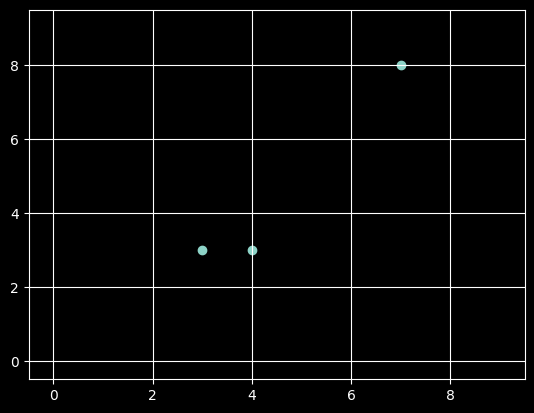

In [13]:
import math

from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt

class Person(Agent):
    def __init__(self, uid, model):
        super().__init__(uid, model)

class City(Model):
    def __init__(self):
        super().__init__()
        self.grid = MultiGrid(10, 10, torus=False)


        self.persons = [Person(1, self), Person(2, self), Person(3, self)]

        for agent, pos in zip(self.persons, [(3, 3), (4, 3), (7, 8)]):
            self.grid.place_agent(agent, pos)

    def show(self):
        xs = [a.pos[0] for a in self.persons]
        ys = [a.pos[1] for a in self.persons]

        plt.grid()
        plt.scatter(xs, ys)
        plt.xlim(-0.5, 9.5)
        plt.ylim(-0.5, 9.5)
        plt.show()

model = City()
model.show()

print(list(model.grid.iter_neighbors((3, 3), moore=True)))

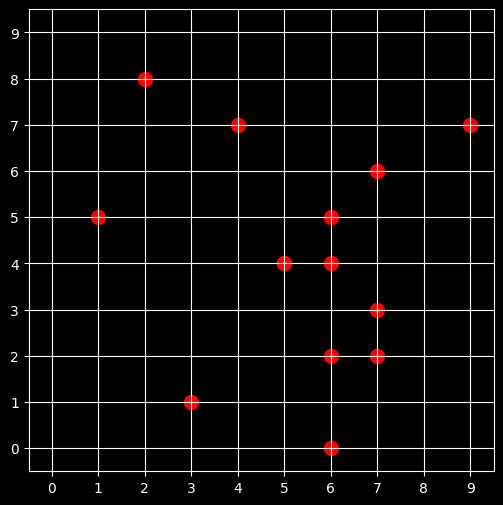

Agent 0 staat op (9, 7) en heeft kleur red
Agent 1 staat op (6, 2) en heeft kleur red
Agent 2 staat op (6, 0) en heeft kleur red
Agent 3 staat op (1, 5) en heeft kleur red
Agent 4 staat op (4, 7) en heeft kleur red
Agent 5 staat op (7, 6) en heeft kleur red
Agent 6 staat op (7, 2) en heeft kleur red
Agent 7 staat op (7, 3) en heeft kleur red
Agent 8 staat op (5, 4) en heeft kleur red
Agent 9 staat op (5, 4) en heeft kleur red
Agent 10 staat op (3, 1) en heeft kleur red
Agent 11 staat op (6, 5) en heeft kleur red
Agent 12 staat op (6, 4) en heeft kleur red
Agent 13 staat op (2, 8) en heeft kleur red


In [2]:
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
import random


class Person(Agent):
    def __init__(self, uid, model, color):
        super().__init__(uid, model)
        self.color = color


class City(Model):
    def __init__(self, width=10, height=10, num_agents=None):
        super().__init__()
        self.grid = MultiGrid(width, height, torus=False)

        # dit zorgt ervoor dat een random aantal agenten op het grid terecht komt.
        if num_agents is None:
            num_agents = random.randint(5, 15)

        self.persons = []
# alle agenten (dus husihoudens) krijgen een rode kleur op het grid
        possible_colors = ["red"]

        for i in range(num_agents):
            color = random.choice(possible_colors)
            person = Person(i, self, color)

            x = random.randint(0, width - 1)
            y = random.randint(0, height - 1)

            self.grid.place_agent(person, (x, y))
            self.persons.append(person)

    def show(self):
        plt.figure(figsize=(6, 6))

        for person in self.persons:
            x, y = person.pos
            plt.scatter(x, y, color=person.color, s=100)

        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.xticks(range(self.grid.width))
        plt.yticks(range(self.grid.height))
        plt.grid(True)
        plt.show()


model = City()
model.show()

for person in model.persons:
    print(f"Agent {person.unique_id} staat op {person.pos} en heeft kleur {person.color}")

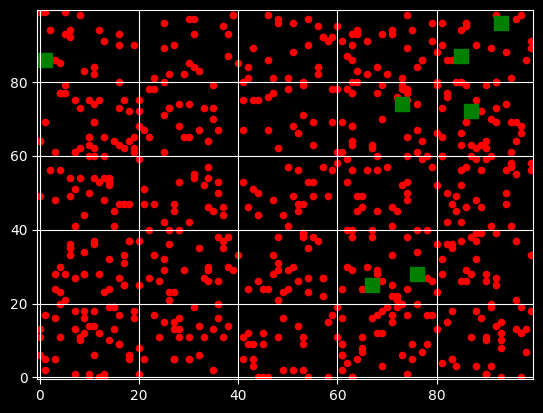

In [19]:
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
import random
import math

#dit is de eerste agent, de huishoudens. nu staan er nog geen variabelen in, maar dat is wat we later wel gaan toevoegen.
class Huishouden(Agent):
    def __init__(self, id, model):
        super().__init__(id, model)

#dit is de tweede agent, de containers. hier komen later ook nog meer karakteristieken bij
class Container(Agent):
    def __init__(self, id, model):
        super().__init__(id, model)

#hierbinnen gaan wij simuleren, deze karakteristieken moeten ook aangepast worden
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=100, people_per_container=250):
        #width is de breedte, height de hoogte, num people aantal personen in de stad, people per container is de variabele die wij nog moeten beargumenteren
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)
        #multi grid houdt in dat er meerdere agents op een plek kunnen syaan, we moeten nadenken of dit wel kan met een huis? ik denk van wel omdat elk vakje een paar km is
        #door de torus stoppen we bij de rand en gaat helemaal rechts niet door links etc

        #lijst met alle huishoudens
        self.huishoudens = []
        #lijst met alle containers
        self.containers = []
        #telt alle unieke ids
        self.id = 0

        #deze formule bereknt het aantal containers aan de hand van de personen. de aantal containers worden altijd afgerond naar boven toe
        num_containers = math.ceil(num_people / people_per_container)

        #plaats de containers die berekend zijn in het grid
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            #dit geeft elke container een unieke plaats binnen de stad
            self.grid.place_agent(c, (random.randint(0, width-1), random.randint(0, height-1)))
            #voeg hem toe aan de lijst van de containers
            self.containers.append(c)

       #plaats de huishoudens in het grid/stad
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            self.grid.place_agent(h, (random.randint(0, width-1), random.randint(0, height-1)))
            self.huishoudens.append(h)

    #elke keer als er een agent gemaakt word gaat het id met 1 omhoog, zo voorkom je dat agents dezelfde id krijgen
    def next_id(self):
        self.id += 1
        return self.id

    def show(self):
        for p in self.huishoudens:
            plt.scatter(p.pos[0], p.pos[1], color="red", s=20)

        for c in self.containers:
            plt.scatter(c.pos[0], c.pos[1], color="green", s=100, marker="s")

        plt.grid()
        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.show()


model = Stad(width=100, height=100, num_people=650, people_per_container=100)
model.show()